# Qwen FG Seg inference (single image)

This notebook runs the FG-seg LoRA with a single input image.

Steps:
1) Download weights into the repo root (see `examples/qwen_image/model_training/qwen_fg_seg_gcs_guide.sh`).
2) Set `INPUT_IMAGE_PATH` below.
3) Run all cells.

Notes:
- Uses `edit_image` only (same as `validate_lora/Qwen-Image-Edit-2511-LayeredVAE_FG_seg.py`).
- Outputs are saved to `output/qwen_fg_seg_infer/`.

In [ ]:
import os
from pathlib import Path

import torch
from PIL import Image
from IPython.display import display

from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig

def _find_repo_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "diffsynth").exists() and (parent / "pyproject.toml").exists():
            return parent
    return start


def _resolve_model_base(repo_root: Path) -> Path:
    env = os.environ.get("DIFFSYNTH_MODEL_BASE_PATH","/mnt/local/diffsynth_models")
    if env:
        return Path(env)
    candidates = [
        repo_root / "diffsynth_models",
        Path("/mnt/lica-data-2/for_jjseol/diffsynth_models"),
        Path("/mnt/data/for_jjseol/diffsynth_models"),
    ]
    for cand in candidates:
        if (cand / "Qwen").exists():
            return cand
    return candidates[0]


REPO_ROOT = _find_repo_root(Path(".").resolve())
DEFAULT_MODEL_BASE = _resolve_model_base(REPO_ROOT)
print(f"[model] base: {DEFAULT_MODEL_BASE}")

# Update this path to your input image

PROMPT = "Extract the foreground layer."
SEED = 123
STEPS = 20

USE_LORA = True

LORA_DIR = REPO_ROOT / "models/train/Qwen-Image-Edit-2511_lora_layered_vae_fg_seg"
LORA_PATH = REPO_ROOT / "models/train/Qwen-Image-Edit-2511_lora_layered_vae_fg_seg/epoch-0.safetensors"

OUTPUT_DIR = REPO_ROOT / "output/qwen_fg_seg_infer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

[model] base: /mnt/local/diffsynth_models


In [2]:
import glob

def _model_config_local_only(local_glob: str, label: str) -> ModelConfig:
    paths = sorted(glob.glob(local_glob))
    if not paths:
        raise FileNotFoundError(f"[model] Missing local weights for {label}: {local_glob}")
    path_value = paths if len(paths) > 1 else paths[0]
    print(f"[model] Using local weights: {path_value}")
    return ModelConfig(path=path_value)


def _aux_config_local_only(local_dir: Path, label: str) -> ModelConfig:
    if not local_dir.exists():
        raise FileNotFoundError(f"[aux] Missing local assets for {label}: {local_dir}")
    print(f"[aux] Using local assets: {local_dir}")
    return ModelConfig(path=str(local_dir))


CUDA_DEVICE_INDEX = 1
if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = f"cuda:{CUDA_DEVICE_INDEX}"
    torch_dtype = torch.bfloat16
else:
    device = "cpu"
    torch_dtype = torch.float32

print(f"[device] {device}")

model_base = DEFAULT_MODEL_BASE
qwen_root = model_base / "Qwen"

pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=torch_dtype,
    device=device,
    model_configs=[
        _model_config_local_only(
            str(qwen_root / "Qwen-Image-Edit-2511" / "transformer" / "diffusion_pytorch_model-*.safetensors"),
            "Qwen-Image-Edit-2511 transformer",
        ),
        _model_config_local_only(
            str(qwen_root / "Qwen-Image" / "text_encoder" / "model*.safetensors"),
            "Qwen-Image text encoder",
        ),
        _model_config_local_only(
            str(qwen_root / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"),
            "Qwen-Image-Layered VAE",
        ),
    ],
    tokenizer_config=None,
    processor_config=_aux_config_local_only(qwen_root / "Qwen-Image-Edit" / "processor", "Qwen-Image-Edit processor"),
)

if USE_LORA:
    if LORA_DIR.is_dir():
        lora_candidates = sorted(LORA_DIR.glob("*.safetensors"), key=lambda p: p.stat().st_mtime)
        if not lora_candidates:
            raise FileNotFoundError(f"No LoRA checkpoints found in: {LORA_DIR}")
        LORA_PATH = lora_candidates[-1]

    if not LORA_PATH.exists():
        raise FileNotFoundError(f"LoRA checkpoint not found: {LORA_PATH}")

    print(f"[lora] Using LoRA: {LORA_PATH}")
    pipe.load_lora(pipe.dit, str(LORA_PATH))

[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00001-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00002-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00003-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00004-of-00005.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00005-of-00005.safetensors']
[model] Using local weights: ['/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors', '/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/mod

Loaded model: {
    "model_name": "qwen_image_dit",
    "model_class": "diffsynth.models.qwen_image_dit.QwenImageDiT",
    "extra_kwargs": null
}
Loading models from: [
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors",
    "/mnt/local/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00004-of-00004.safetensors"
]
Loaded model: {
    "model_name": "qwen_image_text_encoder",
    "model_class": "diffsynth.models.qwen_image_text_encoder.QwenImageTextEncoder",
    "extra_kwargs": null
}
Loading models from: "/mnt/local/diffsynth_models/Qwen/Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsynth.models.qwen_image_vae.QwenImageVAE",
    "extra_kwargs": {
        "image

height % 16 != 0. We round it up to 1088.
width % 16 != 0. We round it up to 1088.


100%|██████████| 50/50 [02:11<00:00,  2.63s/it]


[done] saved to /home/ubuntu/DiffSynth-Studio/output/qwen_fg_seg_infer/BCU2PdSOGeCYHUigtBBj_triplet.png


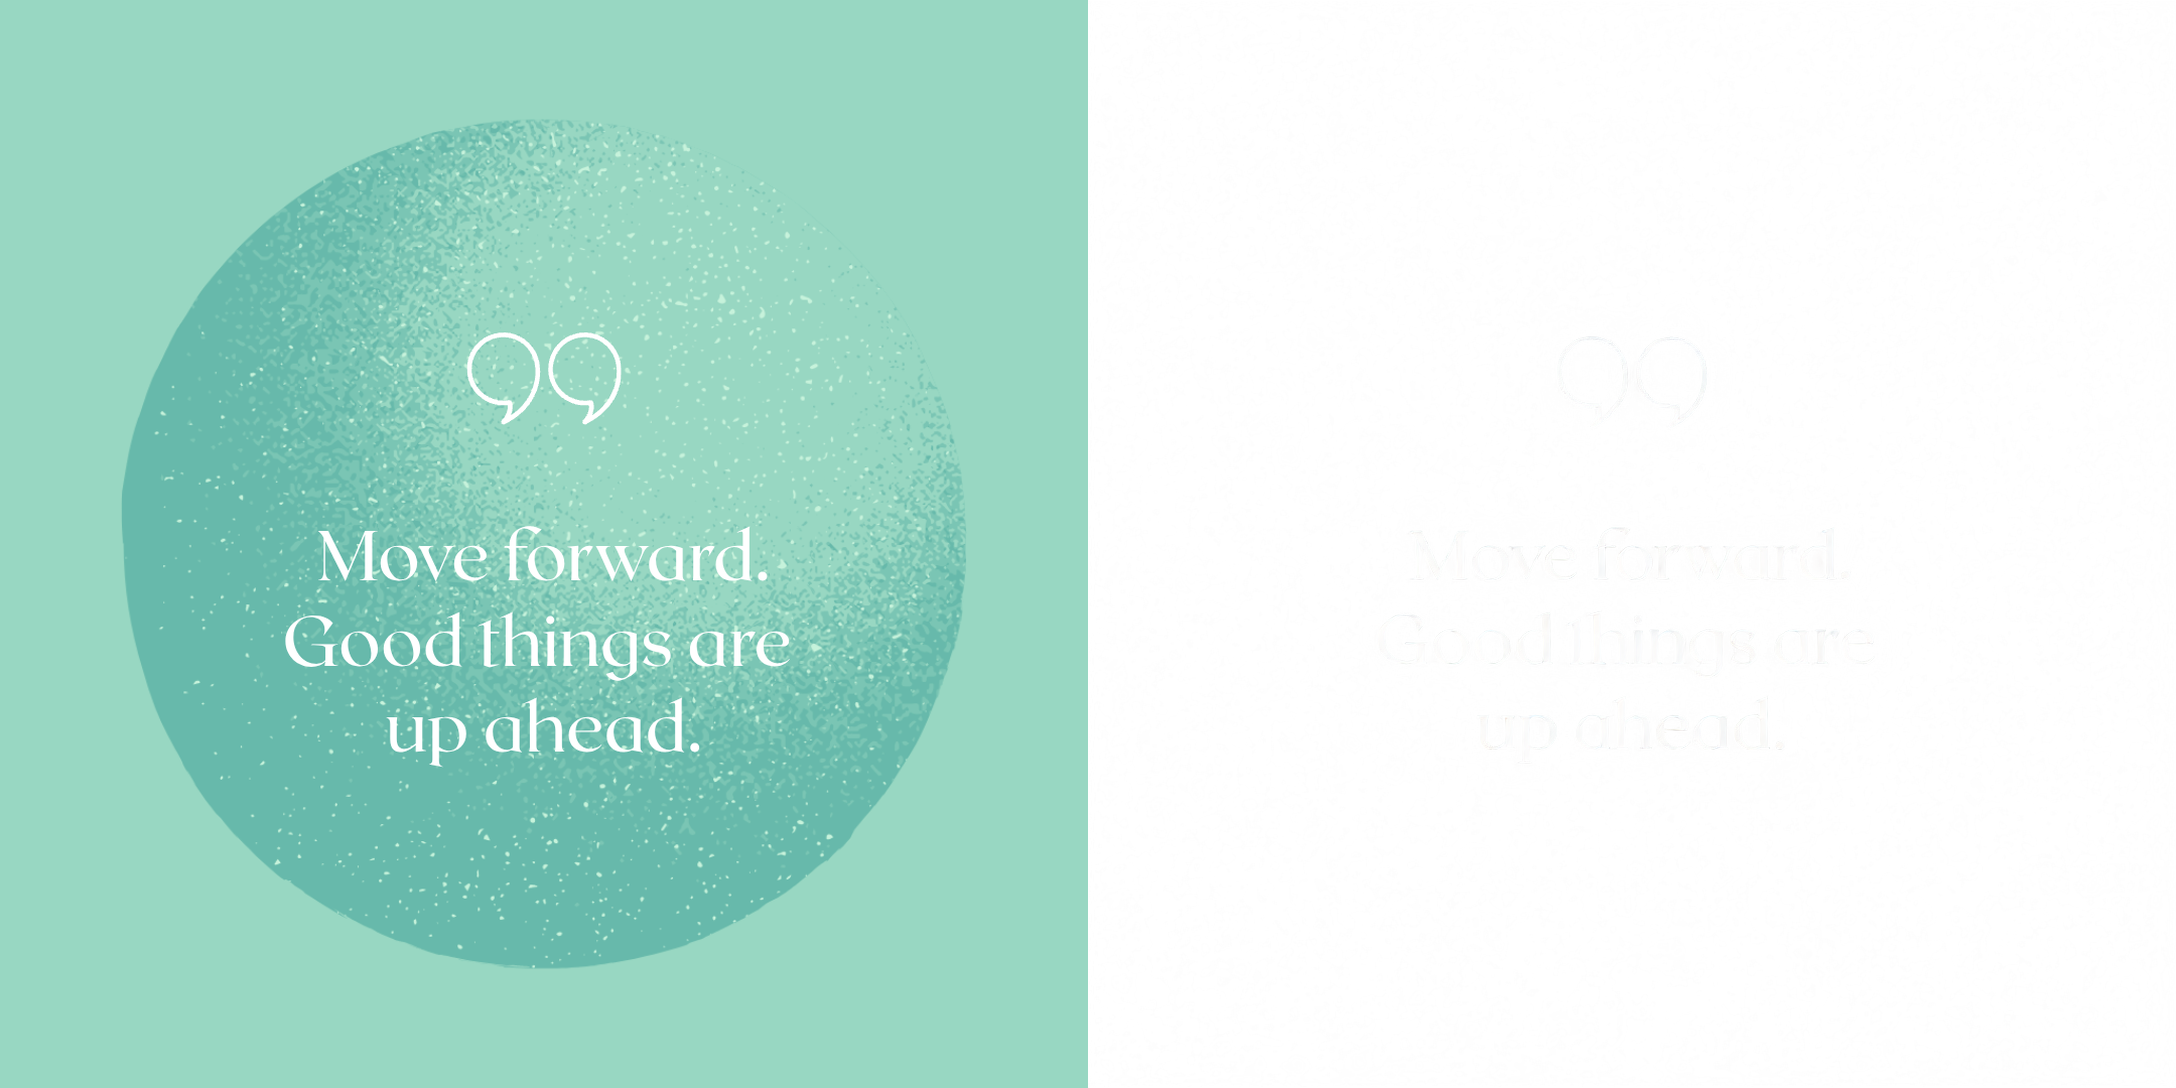

In [4]:
def _checkerboard_rgba(size, tile=32):
    w, h = size
    light = (200, 200, 200, 255)
    dark = (160, 160, 160, 255)
    bg = Image.new("RGBA", size, light)
    tile_img = Image.new("RGBA", (tile, tile), dark)
    for y in range(0, h, tile):
        for x in range(0, w, tile):
            if (x // tile + y // tile) % 2 == 1:
                bg.paste(tile_img, (x, y))
    return bg
INPUT_IMAGE_PATH = Path("/home/ubuntu/BCU2PdSOGeCYHUigtBBj.png")
if not INPUT_IMAGE_PATH.exists():
    raise FileNotFoundError(f"Input image not found: {INPUT_IMAGE_PATH}")

edit_image = Image.open(INPUT_IMAGE_PATH).convert("RGBA")
width, height = edit_image.size

result = pipe(
    PROMPT,
    edit_image=edit_image,
    seed=SEED,
    num_inference_steps=50,#STEPS,
    height=height,
    width=width,
    edit_image_auto_resize=True,
    zero_cond_t=True,
)

# Match output size for display
output_rgba = result.convert("RGBA")
output_size = output_rgba.size
if edit_image.size != output_size:
    edit_image = edit_image.resize(output_size, Image.LANCZOS)

# Build triplet: edit | output | input (input = edit for single-image mode)
checker_bg = _checkerboard_rgba(output_size)
output_composite = output_rgba

out_w, out_h = output_size
canvas = Image.new("RGBA", (out_w * 2, out_h), (0, 0, 0, 0))
canvas.paste(edit_image, (0, 0))
canvas.paste(output_composite, (out_w, 0))

out_path = OUTPUT_DIR / f"{INPUT_IMAGE_PATH.stem}_triplet.png"
canvas.save(out_path)

print(f"[done] saved to {out_path}")
display(canvas)

In [ ]:
# FG-seg on erased images (from qwen_decomposition)
ERASED_RUN_BATCH = False
ERASED_IMAGE_PATH = REPO_ROOT / "output/qwen_decomposition/erased/BCU2PdSOGeCYHUigtBBj_erased.png"
ERASED_ROOT = REPO_ROOT / "output/qwen_decomposition/erased"
ERASED_OUTPUT_DIR = OUTPUT_DIR / "erased_fg_seg"
ERASED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ERASED_PROMPT = PROMPT
ERASED_STEPS = STEPS
ERASED_EDIT_IMAGE_AUTO_RESIZE = False

ERASED_IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}


def _iter_erased_images(root: Path):
    if not root.exists():
        raise FileNotFoundError(f"Erased root not found: {root}")
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in ERASED_IMAGE_EXTS:
            yield path


def _checkerboard_rgba(size, tile=32):
    w, h = size
    light = (200, 200, 200, 255)
    dark = (160, 160, 160, 255)
    bg = Image.new("RGBA", size, light)
    tile_img = Image.new("RGBA", (tile, tile), dark)
    for y in range(0, h, tile):
        for x in range(0, w, tile):
            if (x // tile + y // tile) % 2 == 1:
                bg.paste(tile_img, (x, y))
    return bg


def run_fg_seg_on_erased(image_path: Path, out_dir: Path, seed: int) -> dict:
    edit_image = Image.open(image_path).convert("RGBA")
    width, height = edit_image.size

    result = pipe(
        ERASED_PROMPT,
        edit_image=edit_image,
        seed=seed,
        num_inference_steps=ERASED_STEPS,
        height=height,
        width=width,
        edit_image_auto_resize=ERASED_EDIT_IMAGE_AUTO_RESIZE,
        zero_cond_t=True,
    )

    output_rgba = result.convert("RGBA")
    if edit_image.size != output_rgba.size:
        edit_image = edit_image.resize(output_rgba.size, Image.LANCZOS)

    out_dir.mkdir(parents=True, exist_ok=True)
    fg_path = out_dir / f"{image_path.stem}_fg.png"
    output_rgba.save(fg_path)

    checker_bg = _checkerboard_rgba(output_rgba.size)
    output_composite = Image.alpha_composite(checker_bg, output_rgba)

    canvas = Image.new("RGBA", (output_rgba.width * 2, output_rgba.height), (0, 0, 0, 0))
    canvas.paste(edit_image, (0, 0))
    canvas.paste(output_composite, (output_rgba.width, 0))

    triplet_path = out_dir / f"{image_path.stem}_triplet.png"
    canvas.save(triplet_path)

    return {"fg_path": fg_path, "triplet_path": triplet_path}


if ERASED_RUN_BATCH:
    image_paths = sorted(_iter_erased_images(ERASED_ROOT))
    if not image_paths:
        raise FileNotFoundError(f"No erased images found under: {ERASED_ROOT}")

    for idx, path in enumerate(image_paths):
        rel = path.relative_to(ERASED_ROOT)
        out_dir = ERASED_OUTPUT_DIR / rel.parent
        result = run_fg_seg_on_erased(path, out_dir, seed=SEED + idx)
        print(f"[done] fg: {result['fg_path']}")
        print(f"[done] triplet: {result['triplet_path']}")
else:
    if not ERASED_IMAGE_PATH.exists():
        raise FileNotFoundError(f"Erased image not found: {ERASED_IMAGE_PATH}")

    result = run_fg_seg_on_erased(ERASED_IMAGE_PATH, ERASED_OUTPUT_DIR, seed=SEED)
    print(f"[done] fg: {result['fg_path']}")
    print(f"[done] triplet: {result['triplet_path']}")
    display(Image.open(result["triplet_path"]))


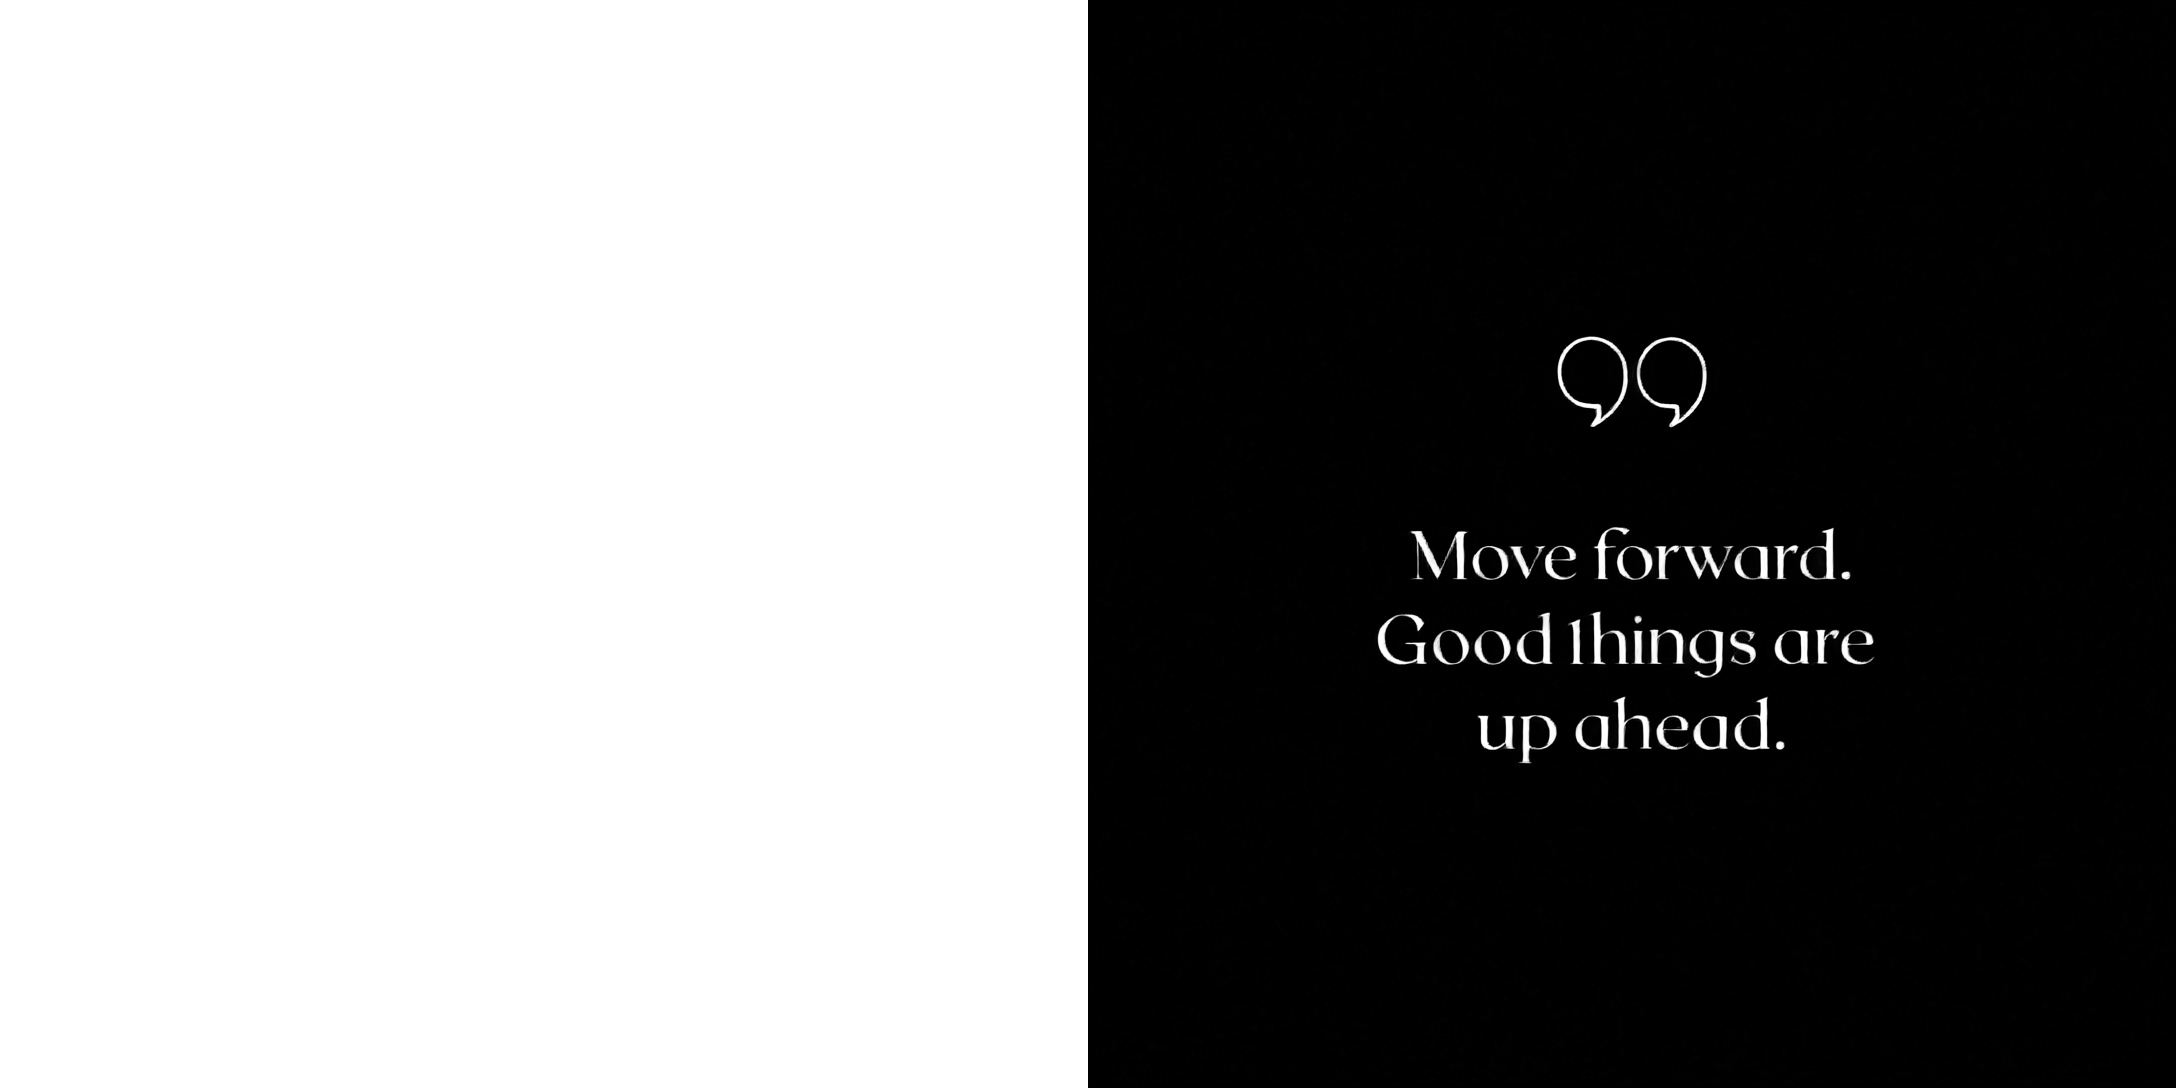

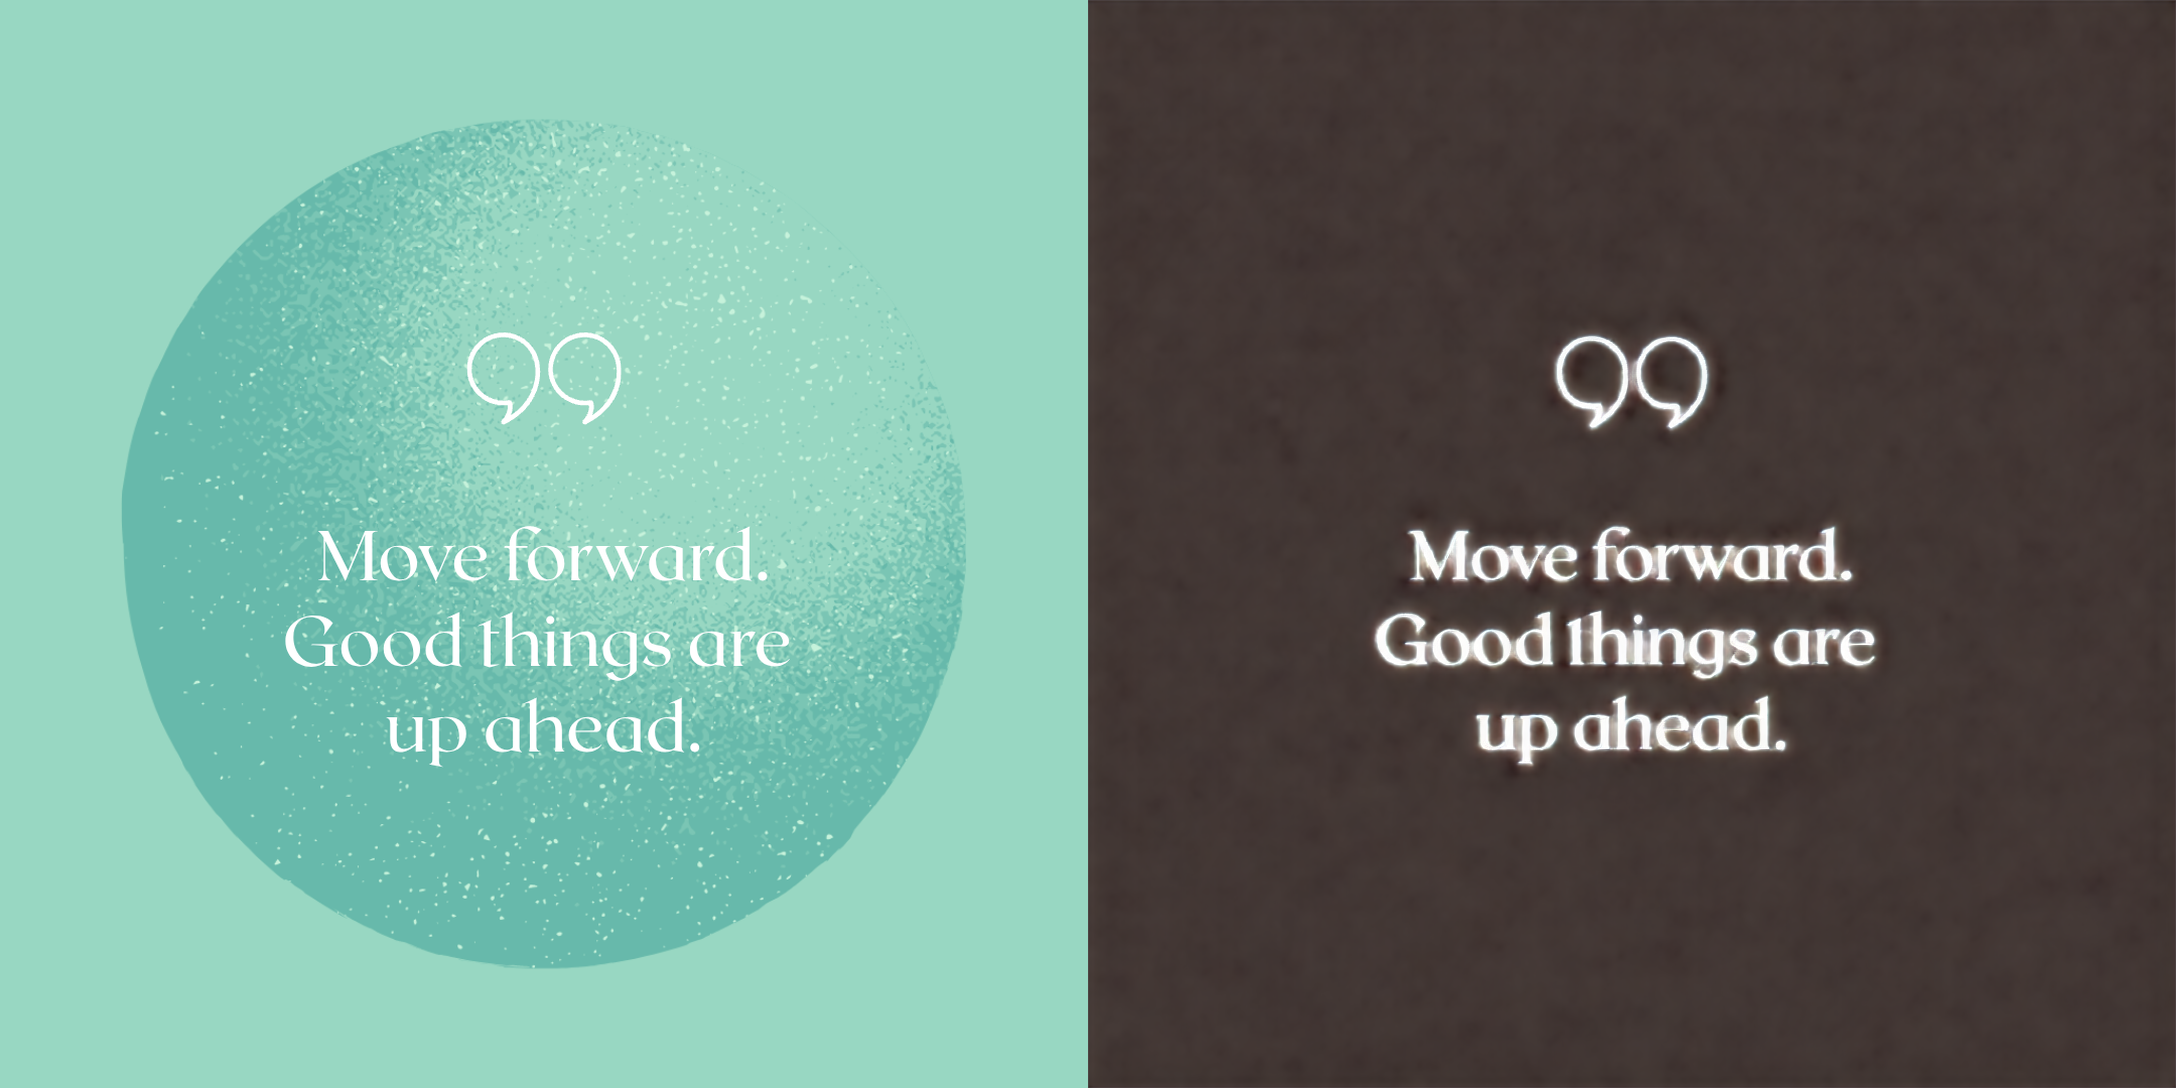

In [5]:
display(canvas.getchannel("A"))
display(canvas.convert("RGB"))